# Analyse des Performances et Benchmarking de l'IA 2048

Cette section est dédiée à la **visualisation des données** issues de nos campagnes de tests. 

L'objectif final est d'identifier la configuration offrant le meilleur **compromis entre score atteint et efficacité temporelle**.


In [4]:
# Algorithme de Visualisation des Résultats du benchmark

import matplotlib.pyplot as plt
import numpy as np

def plot_benchmark_results(labels, scores, times, std_devs=None, title="Comparaison des Performances"):
    """
    Génère un double bar plot comparant les scores (axe gauche) et le temps (axe droit).
    
    Args:
        labels (list): Liste des noms des configurations.
        scores (list): Liste des scores moyens.
        times (list): Liste des temps d'exécution moyens.
        std_devs (list, optional): Liste des écarts-types pour les barres d'erreur.
        title (str): Titre du graphique.
    """
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax1 = plt.subplots(figsize=(14, 8))

    ax1.bar(x - width/2, scores, width, yerr=std_devs, 
            label='Score Moyen', color='skyblue', capsize=5, alpha=0.8)
    ax1.set_xlabel('Configurations', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score Moyen', color='blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax1.set_ylim(0, max(scores) + (max(std_devs) if std_devs else 0) * 1.2 + 5000)

    ax2 = ax1.twinx()
    ax2.bar(x + width/2, times, width, 
            label='Temps Moyen (s)', color='salmon', alpha=0.8)
    ax2.set_ylabel('Temps Moyen par Partie (sec)', color='red', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax2.set_ylim(0, max(times) * 1.2)

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    lines, labels_leg = ax1.get_legend_handles_labels()
    lines2, labels_leg2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels_leg + labels_leg2, loc='upper right')

    fig.tight_layout()
    plt.show()

# Flat Monte Carlo Search

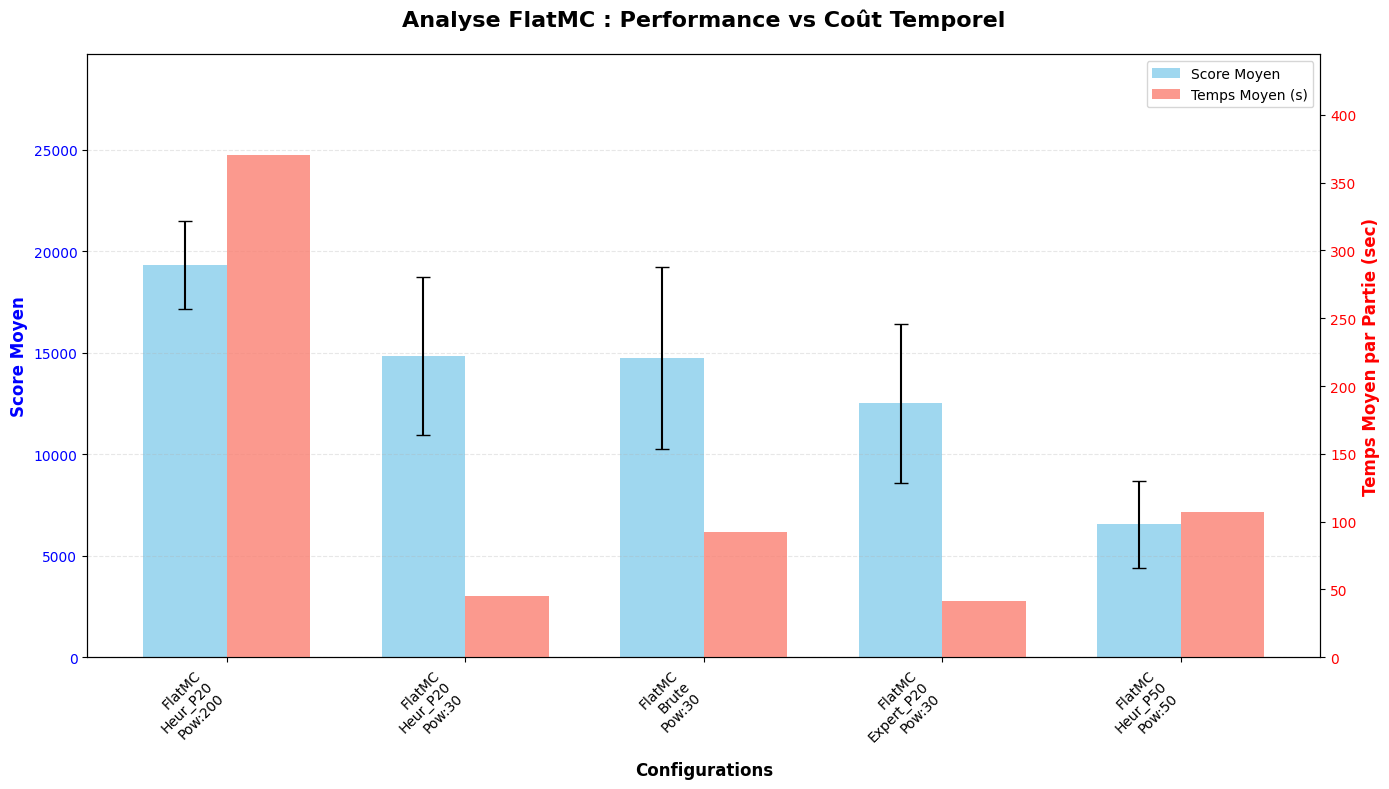

In [5]:
# 1. Données extraites de vos fichiers sources
configs_flatmc = [
    "FlatMC\nHeur_P20\nPow:200", # 
    "FlatMC\nHeur_P20\nPow:30",  # 
    "FlatMC\nBrute\nPow:30",     #
    "FlatMC\nExpert_P20\nPow:30",# 
    "FlatMC\nHeur_P50\nPow:50"   # 
]

scores = [ 19325.20, 14852.80, 14746.40, 12502.00, 6546.40] # 
ecarts = [ 2157.31, 3892.50, 4469.03, 3916.71, 2148.20]      # 
temps  = [ 370.47, 45.55, 92.56, 41.30, 106.91]              # 




# Appel de la fonction
plot_benchmark_results(
    labels=configs_flatmc, 
    scores=scores, 
    times=temps, 
    std_devs=ecarts, 
    title="Analyse FlatMC : Performance vs Coût Temporel"
)

# A retenir : 
# Score : 19991.20
# Ecart : 7133.90
# Temps : 188.49

### Fonctionnement
L'algorithme de Monte Carlo classique (ou "Flat" Monte Carlo) évalue chaque coup possible en lançant de nombreuses simulations aléatoires jusqu'à la fin de la partie. Le meilleur mouvement est alors choisi en fonction du score moyen le plus élevé obtenu lors de ces tests statistiques.

### Démarche suivie

#### Analyse des stratégies de Rollout

Afin d'améliorer les performances de notre algo, nous avons commencé par implémenter différents stratégies de rollout :
- **Brute** : Simulations purement aléatoires (Rollout de base). Cette approche offre de bons résultats mais devient rapidement inefficace à cause de son temps d'exécution exponentiel ( Arriver à une fin de partie est trop long ).
- **Heuristic** : Simulations guidées par une heuristique simple. Nous avons utilisé cette méthode car elle nous permet de réduire considérablement le temps d'exécution tout en maintenant une qualité de jeu acceptable. Pour une profondeur de 20, on avance le jeu de 20 coups puis on évalue l'état du plateau en utilisant une heuristique. (ici, le nombre de cases vides).
- **Expert** : Cette stratégie utilise une fonction d'évaluation multicritères plus complexe :
: 
    - La Monotonie : Pour garantir que les tuiles restent ordonnées et fusionnables.
    - Le Bonus de Coin : Pour forcer l'IA à stabiliser sa plus grosse tuile dans un angle, évitant ainsi de bloquer la grille.
    - La Nombre de cases vides : En récompensant les cases vides résiduelles après la simulation. 

**Conclusion de ces résultats :** Les résultats montrent que l'approche "Heuristic" offre un excellent compromis entre qualité de jeu et temps d'exécution, ainsi nous choisirons cette stratégie pour les tests suivants.

# MCTS avec UCB

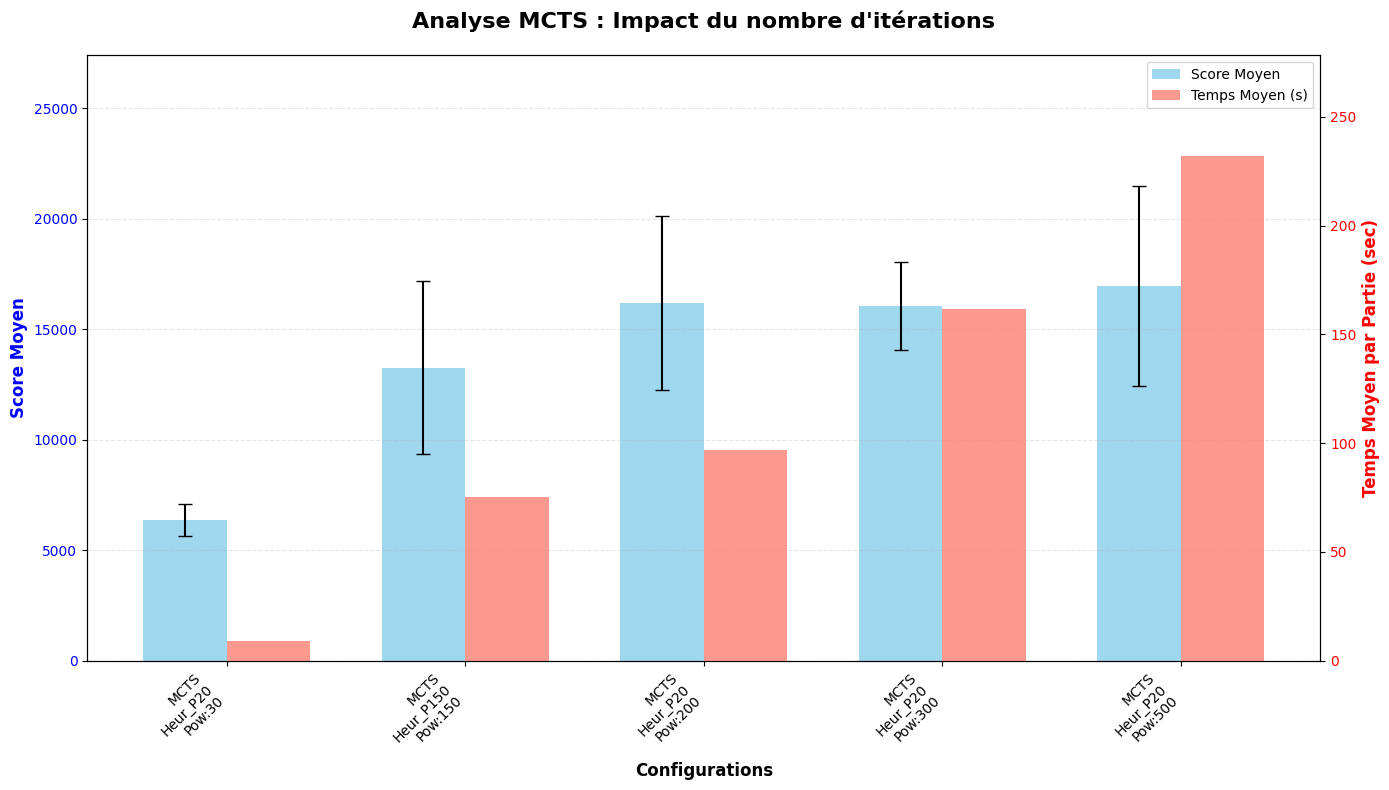

In [6]:
# 1. Données extraites de vos fichiers sources MCTS (ordonnées par itérations)
configs_mcts = [
    "MCTS\nHeur_P20\nPow:30",  # 
    "MCTS\nHeur_P150\nPow:150",# 
    "MCTS\nHeur_P20\nPow:200", # 
    "MCTS\nHeur_P20\nPow:300", # 
    "MCTS\nHeur_P20\nPow:500"  # 
]

# Scores Moyens 
scores_mcts = [6366.00, 13252.00, 16174.40, 16036.40, 16949.60]

# Écarts-types 
ecarts_mcts = [726.90, 3920.60, 3924.44, 1987.60, 4531.51]

# Temps Moyens par partie en secondes 
temps_mcts  = [8.93, 75.13, 96.79, 161.60, 231.88]

# 2. Appel de la fonction de visualisation
plot_benchmark_results(
    labels=configs_mcts, 
    scores=scores_mcts, 
    times=temps_mcts, 
    std_devs=ecarts_mcts, 
    title="Analyse MCTS : Impact du nombre d'itérations"
)

### Fonctionnement
L'algorithme de Monte Carlo Tree Search (MCTS) avec Upper Confidence Bound (UCB) construit un arbre de recherche où chaque nœud représente un état du jeu. L'algorithme sélectionne les nœuds à explorer en utilisant une formule qui équilibre l'exploration et l'exploitation.

### Démarche suivie

Nous avons testé différentes configurations de MCTS en variant les paramètres suivants :
- **Taille de l'arbre** : Nous avons tester des tailles d'arbre différents (200,300,500) pour évaluer l'impact sur les performances de l'IA. 

### Analyse des résultats

Plus la taille de l'arbre est grande, plus l'IA peut explorer de possibilités, mais cela augmente également le temps d'exécution. Mais les résultats montrent que la taille de l'arbre n'a pas un impact significatif sur le score moyen atteints en comparison avec le temps d'exécution.


# NMCS (Nested Monte Carlo Search)

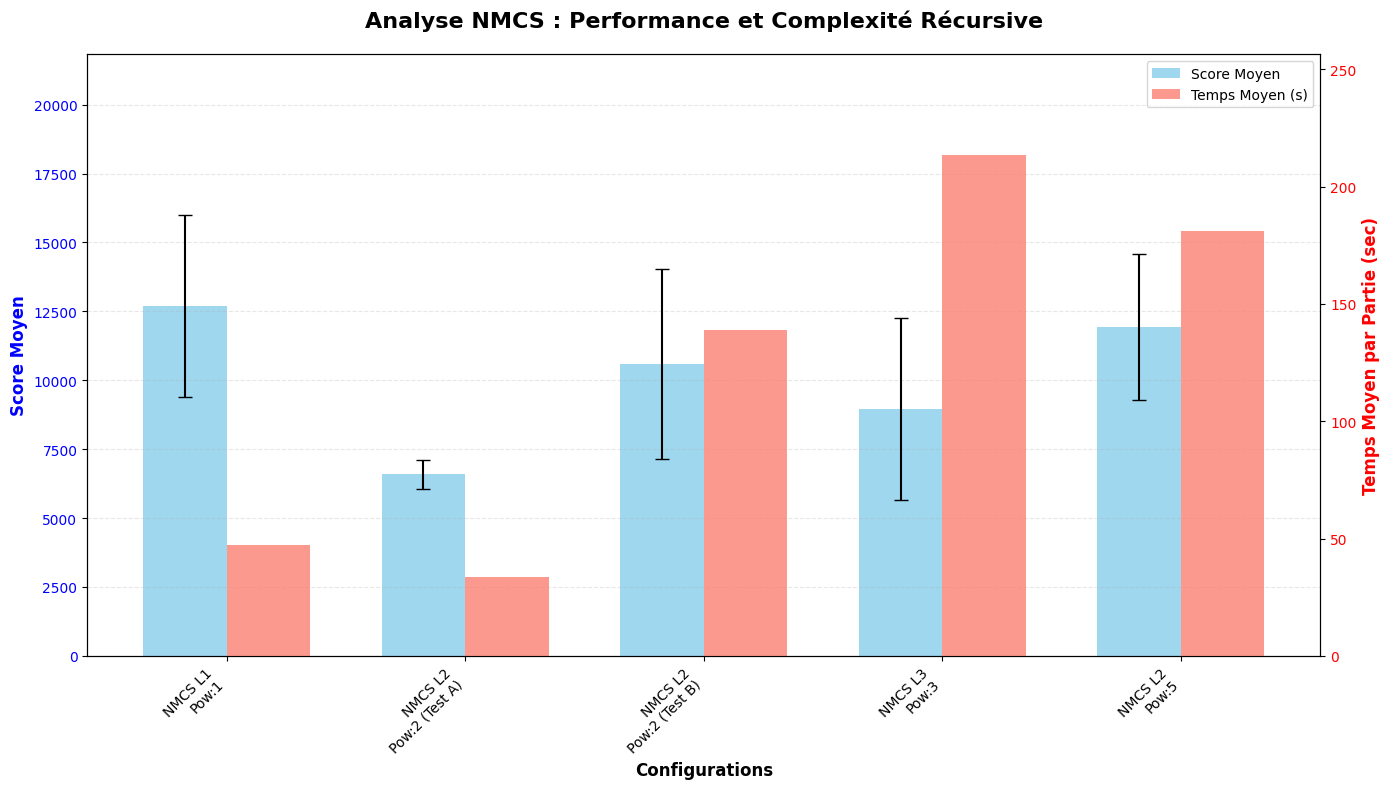

In [7]:
# 1. Données extraites de vos fichiers sources NMCS et MCTS 500
configs_nmcs = [
    "NMCS L1\nPow:1",          # Source 11
    "NMCS L2\nPow:2 (Test A)", # Source 12
    "NMCS L2\nPow:2 (Test B)", # Source 13
    "NMCS L3\nPow:3",          # Source 14
    "NMCS L2\nPow:5",          # Source 15
]

# Scores Moyens
scores_nmcs = [12703.60, 6582.00, 10583.20, 8952.00, 11932.00]

# Écarts-types
ecarts_nmcs = [3300.13, 519.37, 3438.04, 3291.00, 2643.06]

# Temps Moyens par partie en secondes
temps_nmcs  = [47.20, 33.67, 139.07, 213.70, 181.14]

# 2. Appel de la fonction de visualisation
plot_benchmark_results(
    labels=configs_nmcs, 
    scores=scores_nmcs, 
    times=temps_nmcs, 
    std_devs=ecarts_nmcs, 
    title="Analyse NMCS : Performance et Complexité Récursive"
)

### Fonctionnement

L'algorithme de Nested Monte Carlo Search (NMCS) est une extension du Monte Carlo classique qui utilise une approche récursive pour évaluer les coups possibles. Il construit un arbre de recherche où chaque nœud représente un état du jeu, et chaque branche correspond à un coup possible. L'algorithme explore cet arbre en profondeur, en utilisant des simulations pour évaluer les positions.


### Démarche suivie

Nous avons testé différentes configurations de NMCS en variant les paramètres suivants :*
- **niveau de récurision** : Nous avons testé différentes profondeurs (1,2,3). Plus la profondeur est grande, plus l'IA peut explorer de possibilités, mais cela augmente également le temps d'exécution. Les résultats montrent que la profondeur de 2 offre un bon compromis entre score moyen et temps d'exécution.
- **Nombre de simulations par move** : Nous avons également testé différentes valeurs pour le nombre de simulations par coup (1,2,3). Plus le nombre de simulations est élevé, plus le score moyen atteint par l'IA s'améliore, mais cela augmente également le temps d'exécution.

Nous avons aussi voulu accélérer l'algorithme car son temps d'exécution est trop élevé lorsque l'on augment la profondeur et le nombre de simulations par moves. Pour cela, plusieurs méthodes ont été implementées :
- **Caching** : Nous avons mis en place un système de cache pour stocker les résultats des simulations précédentes. Cela permet d'éviter de recalculer les mêmes positions plusieurs fois, réduisant ainsi le temps d'exécution.
- **Pruning** : Nous avons implémenté une technique de pruning pour éliminer les branches de l'arbre qui sont peu prometteuses. En utilisant une heuristique pour évaluer les positions, nous pouvons décider de ne pas explorer certaines branches, ce qui réduit considérablement le temps d'exécution.


### Analyse des résultats

Au final, on remarque ques les résultats fournis par l'algo NMCS ne sont pas très satisfaisants en comparaison avec les autres algorithmes et le temps d'exécution. Ainsi, nous avons décidé de ne pas se concentrer sur ces algorithmes.

# NRPA

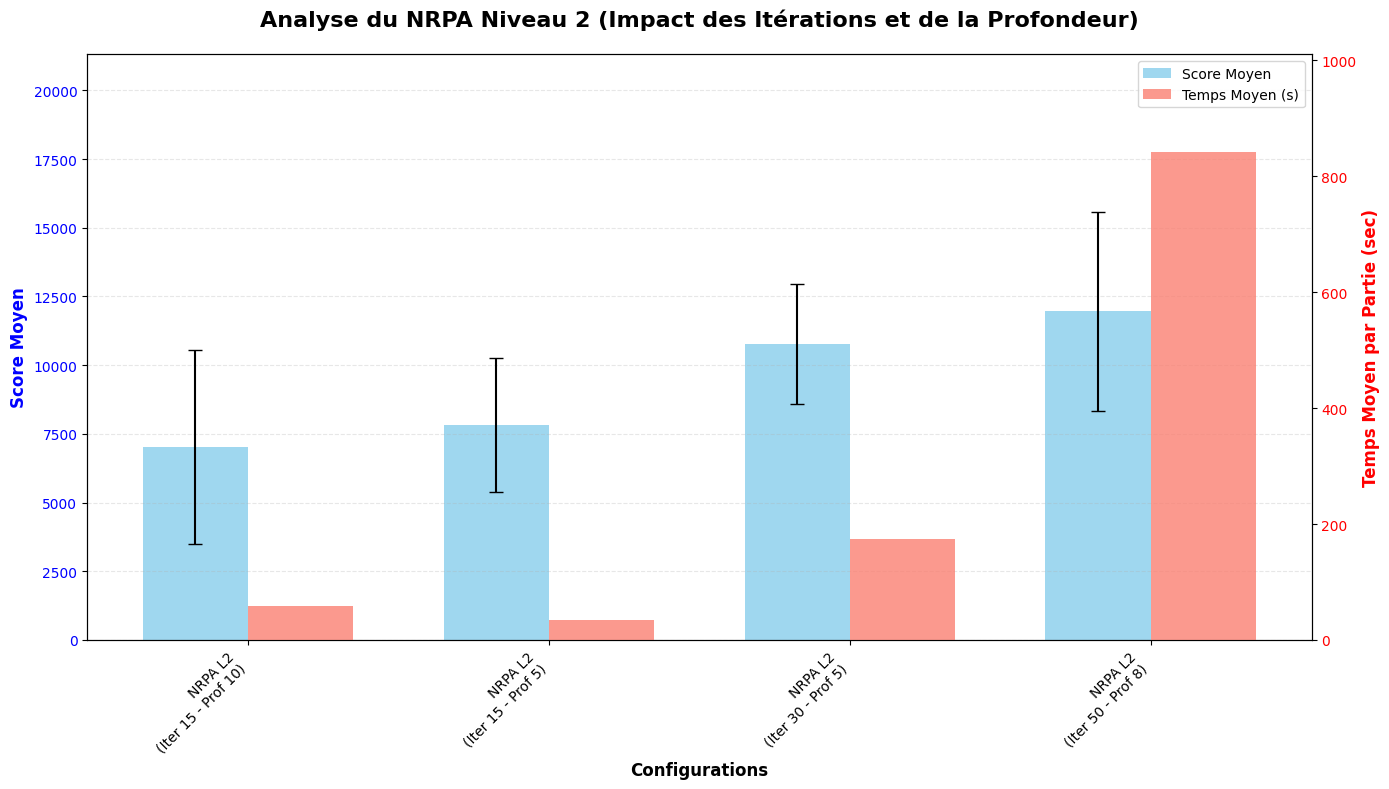

In [ ]:
labels_nrpa = [
    "NRPA L2\n(Iter 15 - Prof 10)", 
    "NRPA L2\n(Iter 15 - Prof 5)", 
    "NRPA L2\n(Iter 30 - Prof 5)",
    "NRPA L2\n(Iter 50 - Prof 8)"
]

# Données extraites de tes fichiers (triées par score croissant)
scores_nrpa = [7030.67, 7820.00, 10761.33, 11954.67]
ecarts_nrpa = [3532.73, 2436.48, 2192.26, 3631.51]
temps_nrpa  = [57.73, 34.37, 174.93, 841.98]

# Génération du graphique
plot_benchmark_results(
    labels=labels_nrpa, 
    scores=scores_nrpa, 
    times=temps_nrpa, 
    std_devs=ecarts_nrpa, 
    title="Analyse du NRPA Niveau 2 (Impact des Itérations et de la Profondeur)"
)

Nous avons voulu tester son évolution logique : le NRPA vu en cours (Nested Rollout Policy Adaptation).

À chaque essai, il retient la séquence de coups qui a donné le meilleur score et met à jour ses probabilités pour orienter ses futures recherches. En gros, l'IA apprend de ses propres réussites pendant qu'elle réfléchit.

Pour le faire fonctionner correctement, nous avons passé pas mal de temps à chercher les bons réglages, notamment sur le compromis entre la profondeur de recherche et le nombre d'itérations. On s'est vite rendu compte d'une chose : le NRPA a surtout besoin de répétitions pour affiner sa politique. Il vaut mieux lui demander de faire beaucoup de simulations courtes (par exemple 5 ou 8 coups d'avance) plutôt que d'essayer de creuser en profondeur. Pour l'aider un peu plus, nous avons remplacé la fin de ses simulations par une heuristique qui évalue le bord.

Le problème de cet algorithme, c'est l'explosion du temps de calcul. Dès que l'on passe au niveau 2, l'exécution devient un trop long (jusqu'à 14 minutes pour une seule partie avec 50 itérations !), tout ça pour un score moyen qui plafonne autour de 12 000.

# Expectimax

L'un des meilleurs algorithmes pour le 2048 est l'Expectimax car, au lieu de générer aléatoirement des milliers de parties et d'aller jusqu'à la fin, on génère toutes les possibilités et on calcule quel coup en moyenne nous donne le meilleur score. Avec une heuristique poussée qui évalue le score d'un plateau (qui fait en sorte que la plus grosse tuile soit dans un coin, puis que les autres se suivent de façon décroissante), on obtient de très bons résultats.
Cependant, cet algorithme n'est pas un MCTS (Monte Carlo Tree Search) à proprement parler, car on ne génère pas de parties aléatoires.

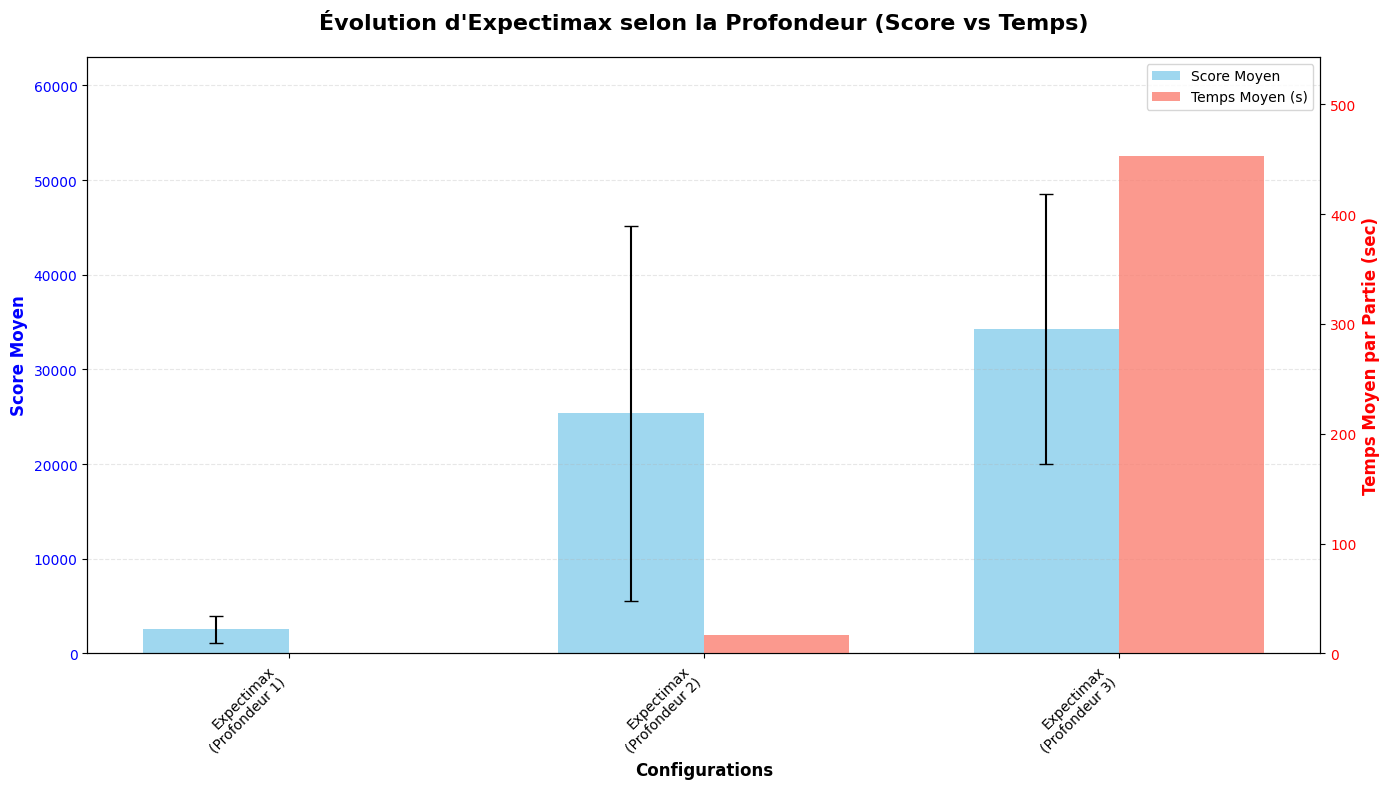

In [10]:
labels_expectimax = [
    "Expectimax\n(Profondeur 1)", 
    "Expectimax\n(Profondeur 2)", 
    "Expectimax\n(Profondeur 3)"
]

# Données extraites des benchmarks
scores_expectimax = [2555.20, 25352.80, 34244.00]
ecarts_expectimax = [1431.74, 19818.37, 14259.69]
temps_expectimax  = [0.09, 16.77, 452.72]

plot_benchmark_results(
    labels=labels_expectimax, 
    scores=scores_expectimax, 
    times=temps_expectimax, 
    std_devs=ecarts_expectimax, 
    title="Évolution d'Expectimax selon la Profondeur (Score vs Temps)"
)




L'algorithme Expectimax surpasse les approches MCTS classiques. À une profondeur de 3, il atteint un score maximal de 51 940, prouvant l'efficacité de l'heuristique qui maintient les tuiles rigoureusement rangées par ordre décroissant.

Cependant, la profondeur 3 souffre de l'explosion combinatoire. Comme excellent compromis entre performance et temps de calcul, la profondeur 2 s'impose comme le choix optimal : elle délivre un score moyen très solide de 25 352 points en seulement 16,7 secondes par partie.

De plus, l'écart type de cette approche est relativement élevé, ce qui suggère que les résultats peuvent varier considérablement d'une partie à l'autre. Cela peut être attribué à la nature stochastique du jeu et à la sensibilité de l'algorithme aux configurations initiales du plateau.

# Conclusion

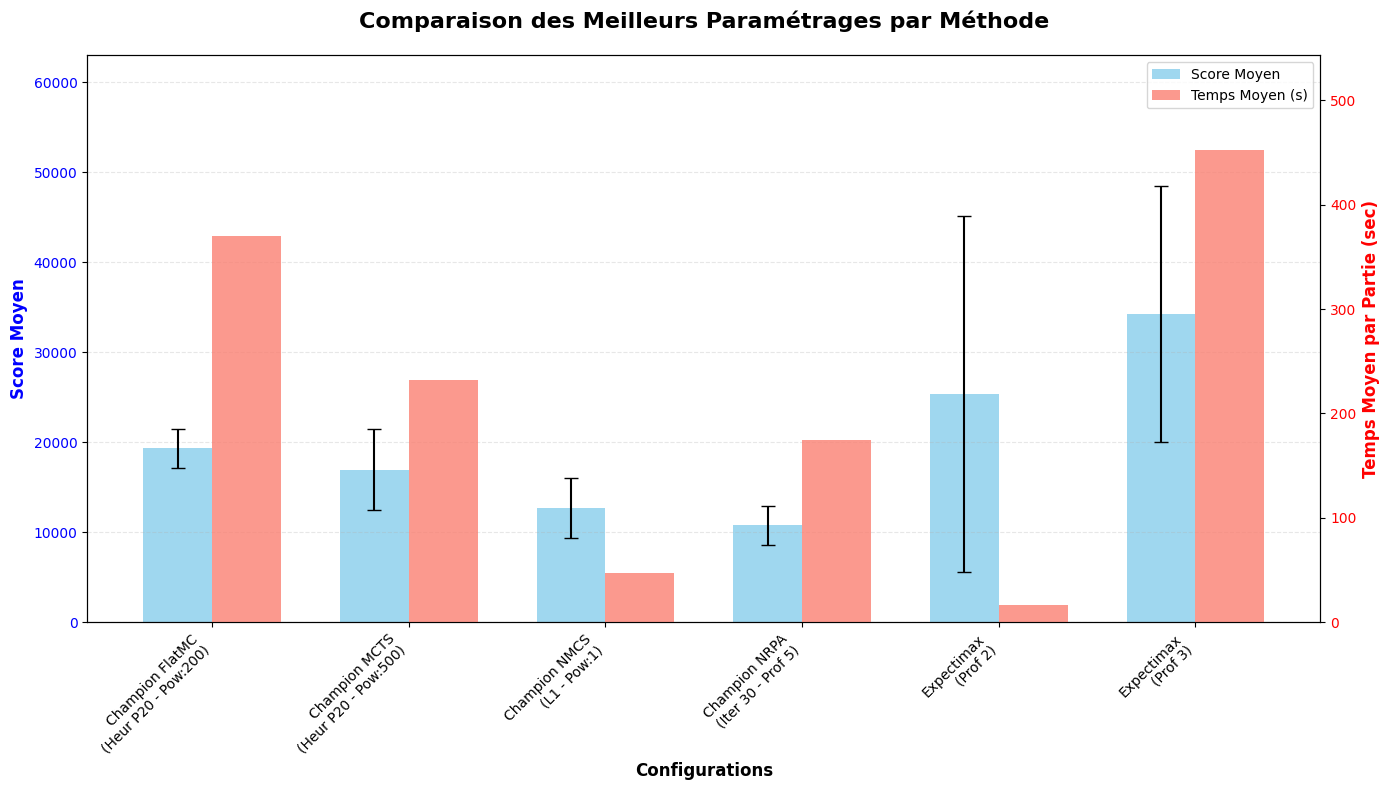

In [11]:
# 1. Sélection des meilleurs résultats de chaque catégorie
labels_champions = [
    "Champion FlatMC\n(Heur P20 - Pow:200)", 
    "Champion MCTS\n(Heur P20 - Pow:500)", 
    "Champion NMCS\n(L1 - Pow:1)",
    "Champion NRPA\n(Iter 30 - Prof 5)",
    "Expectimax\n(Prof 2)",
    "Expectimax\n(Prof 3)"
]

# Scores Moyens des champions
scores_champions = [19325.20, 16949.60, 12703.60, 10761.33, 25352.80, 34244.00] 

# Écarts-types associés
ecarts_champions = [2157.31, 4531.51, 3300.13, 2192.26, 19818.37, 14259.69]

# Temps Moyens par partie associés
temps_champions  = [370.47, 231.88, 47.20, 174.93, 16.77, 452.72]

# 2. Appel de la fonction de visualisation globale
plot_benchmark_results(
    labels=labels_champions, 
    scores=scores_champions, 
    times=temps_champions, 
    std_devs=ecarts_champions, 
    title="Comparaison des Meilleurs Paramétrages par Méthode"
)



**L'Expectimax**, qui sort des méthodes Monte Carlo classiques, est celui qui offre les meilleurs résultats en termes de score. Cependant, l'écart type de cette méthode est trés elevée.  
A une profondeur de 2, cette approche est celui qui nous donne le meilleur compromis entre score et temps de calcul. 
A une profondeur de 3, son temps de calcul devient rapidement complexe à mesure que la profondeur augmente et sa variance est trop élevée fournissant un algo performant mais peu fiable.

**Le Flat Monte Carlo** est une approche plus simple qui peut être efficace avec une bonne stratégie de rollout comme celle heuristique. Elle offre des résultats corrects et plus fiables que l'Expectimax comme le montre le faible écart type.

**Le MCTS avec UCB** est une approche plus sophistiquée qui peut offrir de bonnes performances lorsqu'elle est bien paramétrée. Deplus, elle offre un bon rapport score/temps.